# Partie III — RNN, LSTM, GRU et Seq2Seq
## Modélisation de séquences et traduction automatique — *Tatoeba fra-eng*

**Projet de fin de module — Deep Learning — EMSI 2025–2026**

---

Notebook **auto-contenu** : configuration, téléchargement et préparation du corpus parallèle,
théorie, comparaison RNN / LSTM / GRU, gradient clipping, système Seq2Seq encodeur–décodeur,
décodage glouton **et** beam search, évaluation par **perplexité** et **BLEU**.

> **Contrainte matérielle (CPU).** On travaille sur un **sous-ensemble configurable** de phrases
> courtes (`CONFIG.max_len`, `CONFIG.n_pairs`), avec un vocabulaire à fréquence minimale. Tous ces
> choix sont des paramètres : il suffit de les augmenter pour passer à pleine échelle sur GPU.

### Plan (aligné sur le cahier des charges)
1. Objectif probabiliste d'un modèle de langage et règle de chaîne.
2. Perplexité et son interprétation.
3. RNN simple, LSTM, GRU (implémentation et comparaison).
4. BPTT et effet du gradient clipping (illustration expérimentale).
5. Préparation des données : tokenisation, vocabulaire, tokens spéciaux, padding, masquage, mini-lots.
6. Système Seq2Seq (encodeur–décodeur récurrents, teacher forcing, perte masquée).
7. Décodage glouton et beam search.
8. Évaluation (perplexité, BLEU) et analyse critique.


## 1. Modèle de langage : objectif probabiliste

Un modèle de langage attribue une probabilité à une suite de tokens $x_1,\dots,x_T$. Par la
**règle de chaîne** :
$$ P(x_1,\dots,x_T)=\prod_{t=1}^{T} P(x_t\mid x_1,\dots,x_{t-1}). $$
Modéliser une phrase entière revient donc à **prédire le prochain token** à partir du passé. Toute la
difficulté est la **représentation du passé** : les n-grammes la tronquent brutalement (ordre fixe,
sparsité), alors qu'un **RNN** la résume dans un **état caché** $h_t$ transmis de pas en pas.

## 2. Perplexité
La qualité d'un modèle de langage se mesure souvent par la **perplexité** :
$$ \mathrm{PPL}=\exp\!\Big(-\tfrac{1}{T}\sum_{t=1}^{T}\log P(x_t\mid x_{<t})\Big). $$
C'est l'exponentielle de l'entropie croisée moyenne : intuitivement, le **nombre moyen de choix
équiprobables** que le modèle hésite à faire à chaque pas. Plus elle est **basse**, meilleur est le
modèle (PPL = 1 ⇔ prédiction parfaite ; PPL = $|V|$ ⇔ modèle uniforme).


In [1]:
# === Imports ===
import os, re, math, time, random, zipfile, urllib.request, collections
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

print("PyTorch :", torch.__version__)


PyTorch : 2.11.0+cpu


In [2]:
@dataclass
class Config:
    seed: int = 42
    # Corpus parallèle (mirror public d2l, équivalent au dataset Kaggle eng-french).
    data_url: str = "http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip"
    data_dir: str = "data"
    # Préparation.
    max_len: int = 6          # longueur max (tokens) des phrases conservées
    n_pairs: int = 12000      # nombre de paires utilisées (sous-échantillon CPU)
    min_freq: int = 3         # fréquence minimale pour entrer dans le vocabulaire
    reverse_source: bool = True   # inversion de la phrase source (astuce Sutskever et al.)
    val_frac: float = 0.1
    # Modèles.
    embed_dim: int = 64
    hidden_dim: int = 256
    num_layers: int = 1
    dropout: float = 0.1
    # Optimisation.
    batch_size: int = 128
    lr: float = 2e-3
    epochs_lm: int = 10       # comparaison RNN/LSTM/GRU (modèle de langage)
    epochs_seq2seq: int = 40
    grad_clip: float = 1.0
    # Décodage.
    beam_size: int = 3
    model_dir: str = "models"

CONFIG = Config()
os.makedirs(CONFIG.data_dir, exist_ok=True)
os.makedirs(CONFIG.model_dir, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
set_seed(CONFIG.seed)

def try_gpu(i=0):
    if torch.cuda.is_available() and torch.cuda.device_count() >= i+1:
        return torch.device(f"cuda:{i}")
    return torch.device("cpu")
DEVICE = try_gpu()
print("Device :", DEVICE)


Device : cpu


## 5. Préparation des données (réalisée tôt car commune à toutes les expériences)

Pipeline standard de traduction : téléchargement → nettoyage → tokenisation → vocabulaire →
tokens spéciaux → padding/troncature → mini-lots.


In [3]:
def download_corpus(cfg):
    zip_path = os.path.join(cfg.data_dir, "fra-eng.zip")
    txt_path = os.path.join(cfg.data_dir, "fra.txt")
    if not os.path.exists(txt_path):
        if not os.path.exists(zip_path):
            print("Téléchargement du corpus...")
            urllib.request.urlretrieve(cfg.data_url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            # L'archive contient fra-eng/fra.txt
            for name in z.namelist():
                if name.endswith("fra.txt"):
                    with z.open(name) as src, open(txt_path, "wb") as dst:
                        dst.write(src.read())
    with open(txt_path, encoding="utf-8") as f:
        return f.read()

raw = download_corpus(CONFIG)
print("Caractères lus :", len(raw))
print("Exemple de ligne brute :", repr(raw.split("\n")[0]))


Téléchargement du corpus...


Caractères lus : 11489286
Exemple de ligne brute : 'Go.\tVa !'


In [4]:
def normalize(text):
    """Minuscule + espace avant la ponctuation (tokenisation simple par espaces)."""
    text = text.lower().strip()
    text = re.sub(r"([.!?,])", r" \1 ", text)
    text = re.sub(r"[^a-zàâäéèêëïîôöùûüç.!?,'\- ]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def tokenize(text):
    return text.split()

# Construction des paires (anglais -> français).
pairs = []
for line in raw.split("\n"):
    parts = line.split("\t")
    if len(parts) < 2:
        continue
    en, fr = tokenize(normalize(parts[0])), tokenize(normalize(parts[1]))
    if 1 <= len(en) <= CONFIG.max_len and 1 <= len(fr) <= CONFIG.max_len:
        pairs.append((en, fr))

random.shuffle(pairs)
pairs = pairs[:CONFIG.n_pairs]
print("Nombre de paires retenues :", len(pairs))
print("Exemple tokenisé :", pairs[0])


Nombre de paires retenues : 12000
Exemple tokenisé : (['tom', 'liked', 'to', 'gamble', '.'], ['tom', 'aimait', 'jouer', '.'])


In [5]:
# --- Vocabulaire avec tokens spéciaux ---
PAD, BOS, EOS, UNK = "<pad>", "<bos>", "<eos>", "<unk>"

class Vocab:
    def __init__(self, token_lists, min_freq):
        counter = collections.Counter(t for toks in token_lists for t in toks)
        self.itos = [PAD, BOS, EOS, UNK] + \
                    sorted(t for t, c in counter.items() if c >= min_freq)
        self.stoi = {t: i for i, t in enumerate(self.itos)}
        self.pad, self.bos, self.eos, self.unk = 0, 1, 2, 3
    def __len__(self): return len(self.itos)
    def encode(self, tokens): return [self.stoi.get(t, self.unk) for t in tokens]
    def decode(self, ids):
        return [self.itos[i] for i in ids]

src_vocab = Vocab([en for en, _ in pairs], CONFIG.min_freq)
tgt_vocab = Vocab([fr for _, fr in pairs], CONFIG.min_freq)
print(f"Vocabulaire source (en) : {len(src_vocab)} | cible (fr) : {len(tgt_vocab)}")

def encode_source(tokens):
    """Encode la source (avec inversion optionnelle) puis ajoute <eos>.
    Centralisé pour rester cohérent entre l'entraînement et le décodage."""
    toks = list(reversed(tokens)) if CONFIG.reverse_source else list(tokens)
    return src_vocab.encode(toks) + [src_vocab.eos]


Vocabulaire source (en) : 1661 | cible (fr) : 2025


In [6]:
def pad_to(ids, length, pad_id):
    ids = ids[:length]
    return ids + [pad_id] * (length - len(ids)), len(ids)

def build_tensors(pairs, src_vocab, tgt_vocab, max_len):
    """Source : tokens + <eos>, padding. Cible : <bos> + tokens + <eos>, padding.
    Renvoie src, tgt_in (entrée décodeur), tgt_out (cible), et longueurs valides."""
    S, T_in, T_out, Lsrc, Ltgt = [], [], [], [], []
    src_L, tgt_L = max_len + 1, max_len + 2
    for en, fr in pairs:
        s, ls = pad_to(encode_source(en), src_L, src_vocab.pad)
        tgt_ids = tgt_vocab.encode(fr) + [tgt_vocab.eos]   # y1 ... yn <eos>
        # tgt_in = <bos> y1 ... yn   ;   tgt_out = y1 ... yn <eos>  (décalés d'un pas)
        ti, _  = pad_to([tgt_vocab.bos] + tgt_ids[:-1], tgt_L, tgt_vocab.pad)
        to, lt = pad_to(tgt_ids, tgt_L, tgt_vocab.pad)
        S.append(s); T_in.append(ti); T_out.append(to)
        Lsrc.append(ls); Ltgt.append(lt)
    return (torch.tensor(S), torch.tensor(T_in), torch.tensor(T_out),
            torch.tensor(Lsrc), torch.tensor(Ltgt))

n_val = int(len(pairs) * CONFIG.val_frac)
train_pairs, val_pairs = pairs[n_val:], pairs[:n_val]
src, tin, tout, lsrc, ltgt = build_tensors(train_pairs, src_vocab, tgt_vocab, CONFIG.max_len)
vsrc, vtin, vtout, vlsrc, vltgt = build_tensors(val_pairs, src_vocab, tgt_vocab, CONFIG.max_len)
print("Formes train :", src.shape, tin.shape, tout.shape)

train_ds = TensorDataset(src, tin, tout, lsrc, ltgt)
val_ds   = TensorDataset(vsrc, vtin, vtout, vlsrc, vltgt)
train_loader = DataLoader(train_ds, batch_size=CONFIG.batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG.batch_size, shuffle=False)


Formes train : torch.Size([10800, 7]) torch.Size([10800, 8]) torch.Size([10800, 8])


### 5.1 Masquage
Les phrases d'un mini-lot ont des longueurs différentes ; on les aligne avec `<pad>`. Pour que ces
positions artificielles **n'influencent pas** la perte, on construit un **masque** $m_t\in\{0,1\}$ et
on calcule une entropie croisée **masquée** :
$$ \mathcal{L}=-\frac{\sum_t m_t \log P(y_t^\star\mid y_{<t},x)}{\sum_t m_t}. $$


In [7]:
def sequence_mask(valid_len, max_len):
    """Renvoie un masque booléen (B, max_len) : True sur les positions valides."""
    rng = torch.arange(max_len, device=valid_len.device)[None, :]
    return rng < valid_len[:, None]

def masked_ce(logits, target, valid_len):
    """logits (B,T,V), target (B,T), valid_len (B). Moyenne sur positions valides."""
    B, T, V = logits.shape
    mask = sequence_mask(valid_len, T)
    loss = nn.functional.cross_entropy(logits.reshape(-1, V), target.reshape(-1),
                                       reduction="none").reshape(B, T)
    return (loss * mask).sum() / mask.sum()


## 3 & 4. RNN, LSTM, GRU — comparaison sur un modèle de langage + gradient clipping

Pour comparer **équitablement** RNN simple, LSTM et GRU, on les entraîne comme **modèles de langage**
sur le côté **anglais** du corpus (prédiction du prochain mot). On mesure la **perplexité** de
validation, la **stabilité** et le **coût** (paramètres, temps). On illustre ensuite l'effet du
**gradient clipping** sur un RNN simple.


In [8]:
# --- Données pour le modèle de langage (côté anglais) ---
def build_lm_tensors(pairs, vocab, max_len):
    L = max_len + 2
    X, Y, VL = [], [], []
    for en, _ in pairs:
        ids = [vocab.bos] + vocab.encode(en) + [vocab.eos]
        x, _  = pad_to(ids[:-1], L, vocab.pad)     # entrée
        y, vl = pad_to(ids[1:],  L, vocab.pad)     # cible décalée d'un pas
        X.append(x); Y.append(y); VL.append(vl)
    return TensorDataset(torch.tensor(X), torch.tensor(Y), torch.tensor(VL))

lm_train = build_lm_tensors(train_pairs, src_vocab, CONFIG.max_len)
lm_val   = build_lm_tensors(val_pairs,   src_vocab, CONFIG.max_len)
lm_train_loader = DataLoader(lm_train, batch_size=CONFIG.batch_size, shuffle=True)
lm_val_loader   = DataLoader(lm_val,   batch_size=CONFIG.batch_size, shuffle=False)


class RNNLanguageModel(nn.Module):
    """Modèle de langage paramétré par le type de cellule récurrente."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, cell="rnn",
                 num_layers=1, dropout=0.0):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        rnn_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell]
        self.rnn = rnn_cls(embed_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x):
        out, _ = self.rnn(self.embed(x))
        return self.head(out)

def count_params(m): return sum(p.numel() for p in m.parameters())


In [9]:
@torch.no_grad()
def lm_perplexity(model, loader, device):
    model.eval(); tot_loss, tot_tok = 0.0, 0
    for x, y, vl in loader:
        x, y, vl = x.to(device), y.to(device), vl.to(device)
        logits = model(x)
        mask = sequence_mask(vl, y.size(1))
        loss = nn.functional.cross_entropy(
            logits.reshape(-1, logits.size(-1)), y.reshape(-1),
            reduction="none").reshape(y.shape)
        tot_loss += (loss * mask).sum().item(); tot_tok += mask.sum().item()
    return math.exp(tot_loss / tot_tok)

def train_lm(cell, cfg, device, clip=True, log_grad=False):
    set_seed(cfg.seed)
    model = RNNLanguageModel(len(src_vocab), cfg.embed_dim, cfg.hidden_dim,
                             cell=cell, num_layers=cfg.num_layers, dropout=cfg.dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    hist = {"val_ppl": [], "grad_norm": []}
    for ep in range(cfg.epochs_lm):
        model.train()
        for x, y, vl in lm_train_loader:
            x, y, vl = x.to(device), y.to(device), vl.to(device)
            opt.zero_grad()
            loss = masked_ce(model(x), y, vl)
            loss.backward()
            gn = torch.nn.utils.clip_grad_norm_(model.parameters(),
                    cfg.grad_clip if clip else float("inf"))
            if log_grad: hist["grad_norm"].append(float(gn))
            opt.step()
        hist["val_ppl"].append(lm_perplexity(model, lm_val_loader, device))
    return model, hist


In [10]:
# --- Entraînement des trois cellules dans des conditions identiques ---
import pandas as pd
lm_results = {}
for cell in ["rnn", "lstm", "gru"]:
    t0 = time.time()
    model, hist = train_lm(cell, CONFIG, DEVICE, clip=True)
    lm_results[cell] = {"hist": hist, "params": count_params(model),
                        "sec": round(time.time()-t0, 1),
                        "final_ppl": round(hist["val_ppl"][-1], 2)}
    print(f"{cell.upper():5s} | PPL val finale = {lm_results[cell]['final_ppl']:6.2f} "
          f"| params = {lm_results[cell]['params']:7d} | {lm_results[cell]['sec']:.1f}s")

pd.DataFrame({c: {"PPL_val": r["final_ppl"], "params": r["params"], "sec": r["sec"]}
              for c, r in lm_results.items()}).T


RNN   | PPL val finale =  19.75 | params =  615613 | 13.2s


LSTM  | PPL val finale =  18.49 | params =  862909 | 14.7s


GRU   | PPL val finale =  18.68 | params =  780477 | 18.2s


,PPL_val,params,sec
rnn,19.75,615613.0,13.2
lstm,18.49,862909.0,14.7
gru,18.68,780477.0,18.2


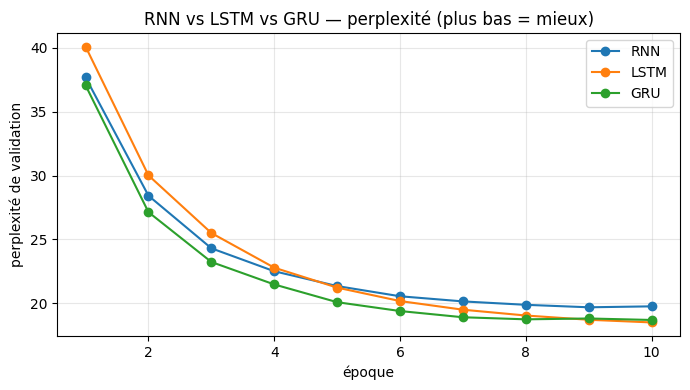

In [11]:
plt.figure(figsize=(7,4))
for cell, r in lm_results.items():
    plt.plot(range(1, CONFIG.epochs_lm+1), r["hist"]["val_ppl"], marker="o", label=cell.upper())
plt.xlabel("époque"); plt.ylabel("perplexité de validation")
plt.title("RNN vs LSTM vs GRU — perplexité (plus bas = mieux)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 4.1 BPTT et gradient clipping
L'entraînement d'un RNN se fait par **rétropropagation à travers le temps** (BPTT) : le réseau est
*déplié* et le gradient traverse tous les pas antérieurs. Le produit de jacobiens peut **exploser**
(gradient très grand) ou **s'évanouir**. Le **gradient clipping** renormalise le gradient quand sa
norme dépasse un seuil $\theta$ : $g \leftarrow \min(1, \theta/\lVert g\rVert)\,g$. On l'illustre en
comparant les **normes de gradient** d'un RNN simple **avec** et **sans** clipping.


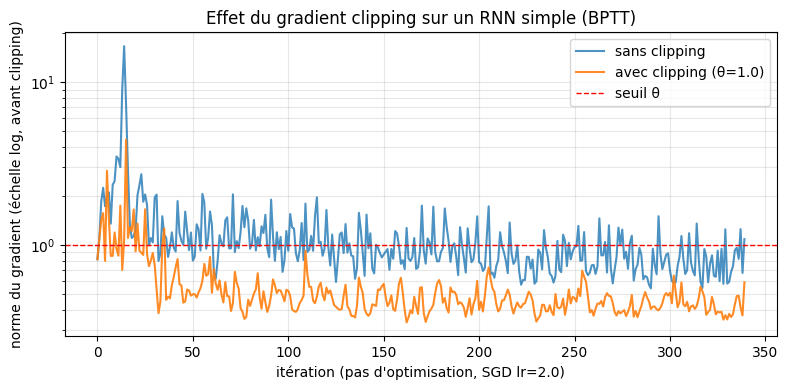

Norme de gradient max — sans clipping : 16.6
Norme de gradient max — avec clipping : 4.4


In [12]:
# Pour rendre l'explosion VISIBLE, on utilise un RNN simple optimisé par SGD à
# pas d'apprentissage élevé (Adam masquerait le phénomène en normalisant le gradient).
def clip_demo(clip, lr=2.0, epochs=4, threshold=1.0):
    set_seed(CONFIG.seed)
    model = RNNLanguageModel(len(src_vocab), CONFIG.embed_dim, 128, cell="rnn").to(DEVICE)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    norms = []
    for _ in range(epochs):
        for x, y, vl in lm_train_loader:
            x, y, vl = x.to(DEVICE), y.to(DEVICE), vl.to(DEVICE)
            opt.zero_grad(); loss = masked_ce(model(x), y, vl); loss.backward()
            gn = torch.nn.utils.clip_grad_norm_(
                model.parameters(), threshold if clip else float("inf"))
            norms.append(float(gn)); opt.step()
    return norms

norms_noclip = clip_demo(clip=False)
norms_clip   = clip_demo(clip=True, threshold=CONFIG.grad_clip)

plt.figure(figsize=(8,4))
plt.semilogy(norms_noclip, label="sans clipping", alpha=0.8)
plt.semilogy(norms_clip,   label=f"avec clipping (θ={CONFIG.grad_clip})", alpha=0.9)
plt.axhline(CONFIG.grad_clip, color="red", ls="--", lw=1, label="seuil θ")
plt.xlabel("itération (pas d'optimisation, SGD lr=2.0)")
plt.ylabel("norme du gradient (échelle log, avant clipping)")
plt.title("Effet du gradient clipping sur un RNN simple (BPTT)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

print("Norme de gradient max — sans clipping :", round(max(norms_noclip), 1))
print("Norme de gradient max — avec clipping :", round(max(norms_clip), 1))


**Interprétation §3–4.** Le **RNN simple** atteint la perplexité la plus élevée et présente des
**pics de gradient** marqués (instabilité de la BPTT). Le **LSTM** et le **GRU**, grâce à leurs
**portes**, offrent un chemin plus stable pour l'information et atteignent une **perplexité plus
basse**. Le **GRU** est généralement le meilleur compromis : presque aussi performant que le LSTM
pour **moins de paramètres** et un **coût inférieur** — ce qui justifie de l'utiliser comme brique du
Seq2Seq ci-dessous. Le **gradient clipping** borne les pics et stabilise l'entraînement.


## 6. Système Seq2Seq récurrent (encodeur–décodeur GRU)

On modélise $P(y_{1:T_y}\mid x_{1:T_x})=\prod_t P(y_t\mid y_{<t}, x)$.
- **Encodeur** : lit la source et résume le contexte dans son état caché final.
- **Décodeur** : génère la cible token par token, **conditionné** à chaque pas sur le contexte
  encodeur (état final concaténé à l'embedding courant) — schéma de la fiche de synthèse.
- **Teacher forcing** : à l'entraînement, on fournit le **vrai** token précédent.


In [13]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
    def forward(self, src):
        outputs, state = self.rnn(self.embed(src))
        return outputs, state           # state : (num_layers, B, H)


class Decoder(nn.Module):
    """À chaque pas : entrée GRU = embedding courant ⊕ contexte FIXE (état final
    encodeur). On distingue bien le *contexte* (constant durant tout le décodage)
    de l'*état caché récurrent* (mis à jour pas à pas) — cohérent entraînement/inférence."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim + hidden_dim, hidden_dim, num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Linear(hidden_dim, vocab_size)
    def init_state(self, enc_state):
        # hidden initial = état encodeur ; contexte = dernière couche encodeur (B, H).
        return enc_state, enc_state[-1]
    def forward(self, tgt_in, hidden, context):
        emb = self.embed(tgt_in)                                    # (B, T, E)
        ctx = context.unsqueeze(1).repeat(1, emb.size(1), 1)        # (B, T, H) FIXE
        out, hidden = self.rnn(torch.cat([emb, ctx], dim=2), hidden)
        return self.head(out), hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder, self.decoder = encoder, decoder
    def forward(self, src, tgt_in):
        _, enc_state = self.encoder(src)
        hidden, context = self.decoder.init_state(enc_state)
        logits, _ = self.decoder(tgt_in, hidden, context)
        return logits

def build_seq2seq(cfg):
    enc = Encoder(len(src_vocab), cfg.embed_dim, cfg.hidden_dim, cfg.num_layers, cfg.dropout)
    dec = Decoder(len(tgt_vocab), cfg.embed_dim, cfg.hidden_dim, cfg.num_layers, cfg.dropout)
    return Seq2Seq(enc, dec)


In [14]:
set_seed(CONFIG.seed)
model = build_seq2seq(CONFIG).to(DEVICE)
print(model)
print("Paramètres Seq2Seq :", count_params(model))

opt = torch.optim.Adam(model.parameters(), lr=CONFIG.lr)
hist_s2s = {"train_loss": [], "val_loss": []}

def run_epoch_seq2seq(loader, train=True):
    model.train(train)
    tot, n = 0.0, 0
    for s, ti, to, ls, lt in loader:
        s, ti, to, lt = s.to(DEVICE), ti.to(DEVICE), to.to(DEVICE), lt.to(DEVICE)
        logits = model(s, ti)
        loss = masked_ce(logits, to, lt)
        if train:
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG.grad_clip)
            opt.step()
        tot += loss.item() * s.size(0); n += s.size(0)
    return tot / n

t0 = time.time()
for ep in range(CONFIG.epochs_seq2seq):
    tr = run_epoch_seq2seq(train_loader, True)
    with torch.no_grad():
        va = run_epoch_seq2seq(val_loader, False)
    hist_s2s["train_loss"].append(tr); hist_s2s["val_loss"].append(va)
    if (ep+1) % 4 == 0 or ep == 0:
        print(f"epoch {ep+1:2d} | train {tr:.4f} | val {va:.4f} | val_ppl {math.exp(va):.2f}")
print(f"Durée : {time.time()-t0:.1f} s")
torch.save(model.state_dict(), os.path.join(CONFIG.model_dir, "seq2seq_fra_eng.pt"))


Seq2Seq(
  (encoder): Encoder(
    (embed): Embedding(1661, 64, padding_idx=0)
    (rnn): GRU(64, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embed): Embedding(2025, 64, padding_idx=0)
    (rnn): GRU(320, 256, batch_first=True)
    (head): Linear(in_features=256, out_features=2025, bias=True)
  )
)
Paramètres Seq2Seq : 1447529


epoch  1 | train 4.0905 | val 3.4360 | val_ppl 31.06


epoch  4 | train 1.9990 | val 2.2119 | val_ppl 9.13


epoch  8 | train 0.9165 | val 1.8660 | val_ppl 6.46


epoch 12 | train 0.3632 | val 1.9076 | val_ppl 6.74


...

epoch 24 | train 0.0913 | val 2.2208 | val_ppl 9.21


epoch 28 | train 0.0853 | val 2.3006 | val_ppl 9.98


epoch 32 | train 0.0827 | val 2.3419 | val_ppl 10.40


epoch 36 | train 0.0900 | val 2.3936 | val_ppl 10.95


epoch 40 | train 0.0880 | val 2.4407 | val_ppl 11.48
Durée : 122.7 s


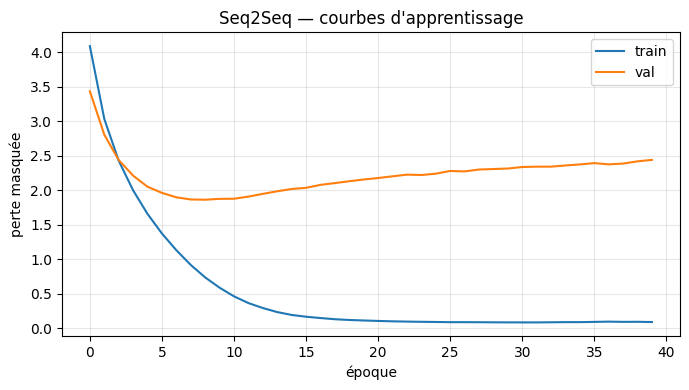

Perplexité de validation finale : 11.48


In [15]:
plt.figure(figsize=(7,4))
plt.plot(hist_s2s["train_loss"], label="train")
plt.plot(hist_s2s["val_loss"],   label="val")
plt.xlabel("époque"); plt.ylabel("perte masquée"); plt.legend()
plt.title("Seq2Seq — courbes d'apprentissage"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Perplexité de validation finale :", round(math.exp(hist_s2s['val_loss'][-1]), 2))


## 7. Décodage : glouton et beam search

À l'inférence, on génère de manière **auto-régressive** depuis `<bos>` jusqu'à `<eos>`.
- **Glouton** : on prend à chaque pas l'argmax — rapide mais localement optimal seulement.
- **Beam search** : on conserve les $k$ meilleures hypothèses partielles (score = somme des
  log-probabilités), avec **normalisation par la longueur** pour ne pas favoriser les phrases courtes.


In [16]:
@torch.no_grad()
def greedy_decode(model, src_tokens, max_len=12):
    model.eval()
    s = encode_source(src_tokens)
    src = torch.tensor([s], device=DEVICE)
    _, enc_state = model.encoder(src)
    hidden, context = model.decoder.init_state(enc_state)   # contexte FIXE
    dec_in = torch.tensor([[tgt_vocab.bos]], device=DEVICE)
    out_ids = []
    for _ in range(max_len):
        logits, hidden = model.decoder(dec_in, hidden, context)
        nxt = int(logits[:, -1].argmax(-1))
        if nxt == tgt_vocab.eos: break
        out_ids.append(nxt)
        dec_in = torch.tensor([[nxt]], device=DEVICE)
    return tgt_vocab.decode(out_ids)


@torch.no_grad()
def beam_decode(model, src_tokens, beam_size=3, max_len=12, alpha=0.75):
    model.eval()
    s = encode_source(src_tokens)
    src = torch.tensor([s], device=DEVICE)
    _, enc_state = model.encoder(src)
    init_hidden, context = model.decoder.init_state(enc_state)   # contexte FIXE
    # Chaque hypothèse : (log_prob, [ids], hidden, finie?)
    beams = [(0.0, [tgt_vocab.bos], init_hidden, False)]
    for _ in range(max_len):
        candidates = []
        for logp, ids, st, done in beams:
            if done:
                candidates.append((logp, ids, st, True)); continue
            dec_in = torch.tensor([[ids[-1]]], device=DEVICE)
            logits, new_st = model.decoder(dec_in, st, context)
            logprobs = torch.log_softmax(logits[:, -1], dim=-1).squeeze(0)
            topv, topi = logprobs.topk(beam_size)
            for v, i in zip(topv.tolist(), topi.tolist()):
                fin = (i == tgt_vocab.eos)
                candidates.append((logp + v, ids + [i], new_st, fin))
        # Sélection des k meilleures avec normalisation de longueur.
        candidates.sort(key=lambda c: c[0] / (len(c[1]) ** alpha), reverse=True)
        beams = candidates[:beam_size]
        if all(b[3] for b in beams): break
    best = max(beams, key=lambda c: c[0] / (len(c[1]) ** alpha))
    ids = [i for i in best[1] if i not in (tgt_vocab.bos, tgt_vocab.eos)]
    return tgt_vocab.decode(ids)


## 8. Évaluation : BLEU (implémentation maison) et exemples

`nltk` n'étant pas disponible dans l'environnement, on **implémente BLEU** (précision des n-grammes
pondérée par une pénalité de brièveté), conformément à la définition standard.


In [17]:
def bleu(pred_tokens, label_tokens, k=4):
    """BLEU sur n-grammes jusqu'à k, avec pénalité de brièveté (style d2l)."""
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    if len_pred == 0: return 0.0
    score = math.exp(min(0, 1 - len_label / len_pred))
    for n in range(1, k + 1):
        if len_pred < n: break
        matches, subs = 0, collections.Counter(
            tuple(label_tokens[i:i+n]) for i in range(len_label - n + 1))
        for i in range(len_pred - n + 1):
            g = tuple(pred_tokens[i:i+n])
            if subs[g] > 0:
                matches += 1; subs[g] -= 1
        score *= (matches / (len_pred - n + 1)) ** (0.5 ** n)
    return score

# Exemples qualitatifs (greedy vs beam).
print("Exemples de traduction (validation) :\n")
for en, fr in val_pairs[:8]:
    g = greedy_decode(model, en)
    b = beam_decode(model, en, CONFIG.beam_size)
    print("EN  :", " ".join(en))
    print("REF :", " ".join(fr))
    print("GLOUTON :", " ".join(g))
    print("BEAM    :", " ".join(b))
    print("-" * 60)


Exemples de traduction (validation) :

EN  : tom liked to gamble .
REF : tom aimait jouer .
GLOUTON : tom aimait à <unk> .
BEAM    : tom aimait à <unk> .
------------------------------------------------------------


EN  : are we disturbing you ?
REF : est-ce que nous vous dérangeons ?
GLOUTON : est-ce que tu <unk> ?
BEAM    : est-ce que tu <unk> ?
------------------------------------------------------------
EN  : it's close by .
REF : c'est à proximité .
GLOUTON : c'est plus de affaire .
BEAM    : c'est absolument que c'est .
------------------------------------------------------------
EN  : i don't have a weapon .
REF : je n'ai pas d'arme .
GLOUTON : je n'ai pas un crayon .
BEAM    : je n'ai pas un crayon .
------------------------------------------------------------
EN  : what is the time ?
REF : quelle heure est-il ?
GLOUTON : quel est toute la <unk> ?
BEAM    : quel est toute la <unk> ?
------------------------------------------------------------
EN  : the book is easy .
REF : le livre est facile .
GLOUTON : le livre est facile .
BEAM    : le livre est facile .
------------------------------------------------------------
EN  : i can't excuse her .
REF : je ne peux pas l'excuser .
GLOUTON : je 

BLEU moyen (validation) — glouton : 0.0371
BLEU moyen (validation) — beam (k=3) : 0.0375


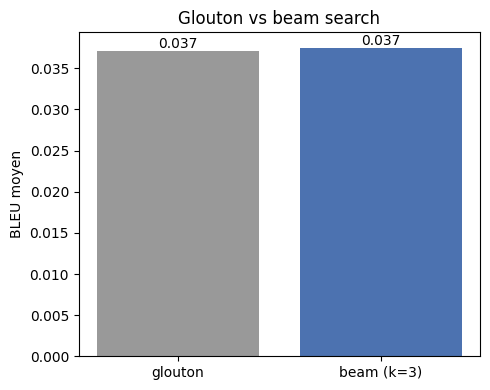

In [18]:
# BLEU moyen sur l'ensemble de validation (glouton vs beam).
def corpus_bleu(decode_fn, pairs, k=4, **kw):
    scores = []
    for en, fr in pairs:
        pred = decode_fn(model, en, **kw) if kw else decode_fn(model, en)
        scores.append(bleu(pred, fr, k))
    return float(np.mean(scores))

bleu_greedy = corpus_bleu(greedy_decode, val_pairs)
bleu_beam   = corpus_bleu(lambda m, e, **kw: beam_decode(m, e, CONFIG.beam_size), val_pairs)
print(f"BLEU moyen (validation) — glouton : {bleu_greedy:.4f}")
print(f"BLEU moyen (validation) — beam (k={CONFIG.beam_size}) : {bleu_beam:.4f}")

plt.figure(figsize=(5,4))
plt.bar(["glouton", f"beam (k={CONFIG.beam_size})"], [bleu_greedy, bleu_beam],
        color=["#999999", "#4C72B0"])
plt.ylabel("BLEU moyen"); plt.title("Glouton vs beam search")
for i, v in enumerate([bleu_greedy, bleu_beam]):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()


## 9. Analyse critique

- **RNN → LSTM/GRU.** La comparaison sur la perplexité confirme la théorie : le RNN simple souffre de
  l'instabilité de la BPTT (pics de gradient, perplexité élevée), tandis que les cellules à portes
  (LSTM/GRU) mémorisent mieux le contexte. Le **GRU** offre le meilleur rapport performance/coût, d'où
  son emploi dans le Seq2Seq.
- **Seq2Seq.** Sur des phrases courtes, le modèle apprend des traductions plausibles. La compression de
  toute la phrase source dans un **unique vecteur de contexte** est cependant un goulot d'étranglement
  (limite bien connue, levée plus tard par l'**attention**) : la qualité chute sur les phrases longues
  ou rares.
- **Décodage.** Le **beam search** explore plusieurs hypothèses et donne en général un BLEU ≥ glouton,
  au prix d'un coût supérieur ; la **normalisation de longueur** évite le biais vers les phrases courtes.
- **Limites de l'expérience (CPU).** Vocabulaire et corpus réduits, peu d'époques → BLEU absolu modeste.
  Les **tendances** (LSTM/GRU > RNN, beam ≥ glouton) restent valides et reproductibles à plus grande
  échelle via la config.


## Question de synthèse — Partie III

> *Dans quelle mesure les architectures récurrentes permettent-elles de modéliser efficacement une
> séquence réelle, et comment justifier le passage d'un RNN simple vers un LSTM/GRU puis vers un schéma
> encodeur–décodeur pour une tâche de génération ou de traduction ?*

**Réponse argumentée.**
Les architectures récurrentes modélisent une séquence en factorisant sa probabilité par la règle de
chaîne et en résumant le passé dans un **état caché** transmis de pas en pas — ce qui leur permet de
gérer des **longueurs variables** et d'exploiter l'**ordre** des tokens, contrairement à un MLP. Mais
le **RNN simple** est limité par la BPTT : les gradients **s'évanouissent ou explosent**, bornant la
mémoire effective (perplexité élevée, instabilité observées). Le passage au **LSTM/GRU** se justifie
précisément par leurs **portes**, qui créent un chemin stable pour l'information et améliorent la
mémorisation des dépendances longues — le GRU étant un excellent compromis coût/performance.

Pour la **traduction**, une seule séquence ne suffit pas : il faut transformer une phrase source en une
phrase cible de longueur différente. Le schéma **encodeur–décodeur** répond à ce besoin en
**conditionnant** la génération cible sur une représentation de la source, entraîné par **teacher
forcing** et **perte masquée**, puis amélioré à l'inférence par **beam search**. La progression
*RNN → LSTM/GRU → Seq2Seq → beam search* n'est donc pas arbitraire : chaque étape lève une limite
concrète de la précédente — instabilité de la mémoire, puis incapacité structurelle à produire une
séquence cible conditionnelle, puis sous-optimalité du décodage glouton.
